In [ ]:
# 03 — Causal Uplift Modeling
AIPW/DR ATE and T-learner uplift with XGBoost

In [2]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [9]:
import xgboost
xgboost.__version__

'3.0.5'

In [5]:
from src.simulate import make_synthetic
from src.causal import aipw_ate, t_learner_cate
from src.metrics import uplift_curve

In [6]:
df = make_synthetic(n=150_000)
X = [c for c in df.columns if c.startswith('x')]
dr = aipw_ate(df, y='y', t='t', X=X)
uplift = t_learner_cate(df, y='y', t='t', X=X)
curve = uplift_curve(df, uplift)
dr, curve.head()

/Users/entejar/Library/CloudStorage/OneDrive-TheUniversityofTexasatAustin/GitHub/causal-ab-testing/src/metrics.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = d.groupby("_decile").apply(


(0.37985744548618666,
    decile    uplift
 0       9  3.418725
 1       8  1.146970
 2       7  0.673827
 3       6  0.346179
 4       5  0.106694)

In [7]:
import pandas as pd

def summarize_uplift(dr, curve, k=5):
    print(f"Average Treatment Effect (AIPW): {dr:.3f}\n")
    print("Top uplift deciles:")
    display(curve.head(k))

summarize_uplift(dr, curve)

Average Treatment Effect (AIPW): 0.380

Top uplift deciles:


,decile,uplift
0,9,3.418725
1,8,1.146970
2,7,0.673827
3,6,0.346179
4,5,0.106694


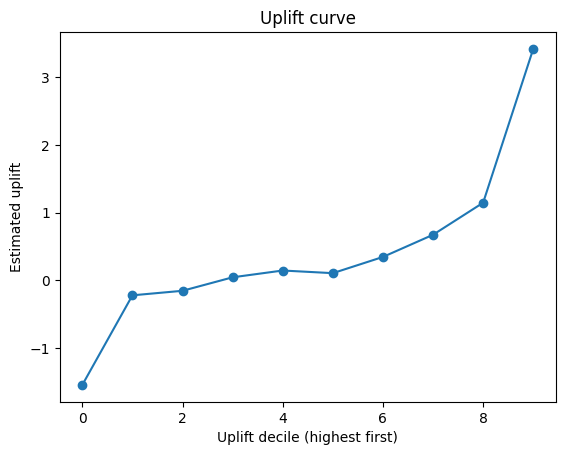

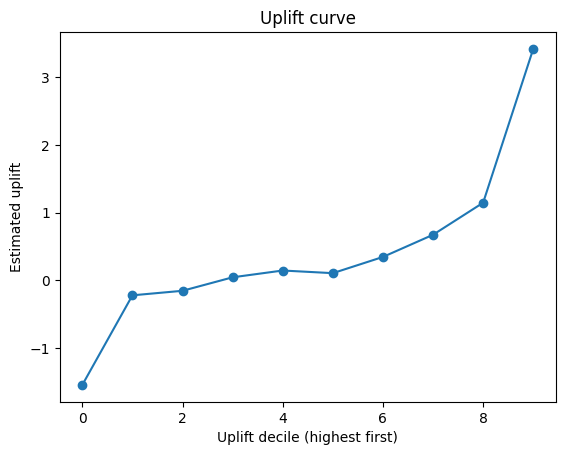

In [8]:
from src.viz import plot_uplift
plot_uplift(curve)